# 01 - Exploration of the UFC data

What the master table contains, and the properties of the data that shape the modelling choices. It reads `data/processed/master.csv`, written by [UFC_Pipeline](../UFC_Pipeline.ipynb): run that notebook first.

1. Coverage
2. The corner artefact
3. How fights end
4. Data quality
5. The betting market

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from ufc_rating import plotting
from ufc_rating.config import DIVISIONS, MASTER_CSV
from ufc_rating.processing.master import american_to_prob, read_master

plotting.setup()
master = read_master(MASTER_CSV)
master['year'] = master['date'].dt.year

## 1. Coverage

8,828 fights, 784 events, 2,738 fighters
From 1993-11-12 (UFC 1) to 2026-08-08


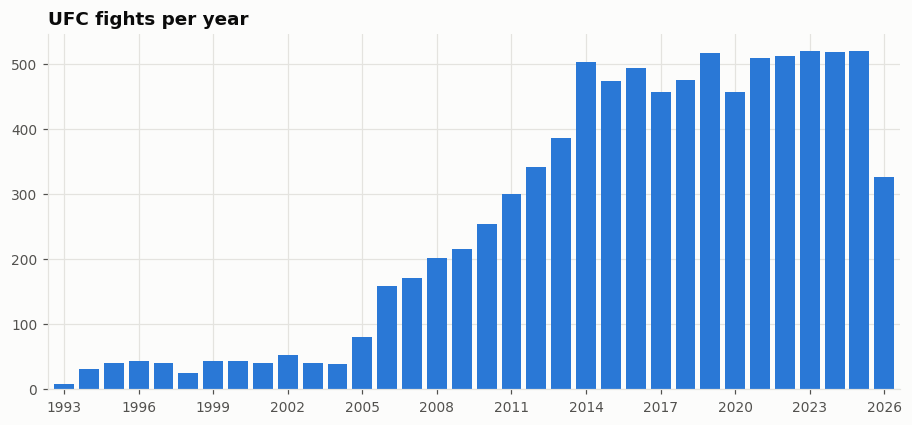

In [2]:
fighters = pd.concat([master['r_id'], master['b_id']]).nunique()
print(f"{len(master):,} fights, {master['event_id'].nunique():,} events, {fighters:,} fighters")
print(f"From {master['date'].min().date()} (UFC 1) to {master['date'].max().date()}")

per_year = master.groupby('year').size()
ax = per_year.plot.bar(width=0.8, color=plotting.BLUE)
ax.set_title('UFC fights per year')
ax.set_xlabel('')
ax.set_xticks(range(0, len(per_year), 3))
ax.set_xticklabels(per_year.index[::3], rotation=0)
plt.show()

The UFC ran a handful of events a year until the mid-2000s. The Fight Night format, the TV deals and the international cards then pushed it to 400-500 fights a year. Most of the data, and therefore most of what the models learn, comes from the last fifteen years.

In [3]:
divisions = (master.dropna(subset=['division'])
             .groupby('division')
             .agg(fights=('fight_id', 'size'), first=('date', 'min'), last=('date', 'max'))
             .reindex(DIVISIONS))
divisions['first'] = divisions['first'].dt.date
divisions['last'] = divisions['last'].dt.date
unassigned = master['division'].isna().sum()
print(f'{unassigned} fights without a division (catch weight, open weight, early tournaments)')
divisions

207 fights without a division (catch weight, open weight, early tournaments)


,fights,first,last
division,,,
Flyweight,424,2012-03-02,2026-07-25
Bantamweight,794,2010-12-04,2026-08-01
Featherweight,877,2010-12-04,2026-08-08
Lightweight,1472,1997-02-07,2026-08-08
Welterweight,1410,1998-10-16,2026-08-08
Middleweight,1160,1997-07-27,2026-08-01
Light Heavyweight,769,1997-12-21,2026-08-08
Heavyweight,784,1997-02-07,2026-08-08
Women's Strawweight,374,2014-07-16,2026-08-08


The twelve divisions did not all exist from the start: women's MMA arrived in 2013, flyweight in 2012 and women's featherweight is a small division. The fights labelled "catch weight" or "open weight" have no division; they still count in the fighters' records.

## 2. The corner artefact

Each fight lists two fighters, `r` then `b`. On modern cards `r` is the red corner, usually given to the favourite or the champion. But on ufcstats.com the **winner is listed first in every fight before 2010**: the "red corner" of those years is not a corner at all.

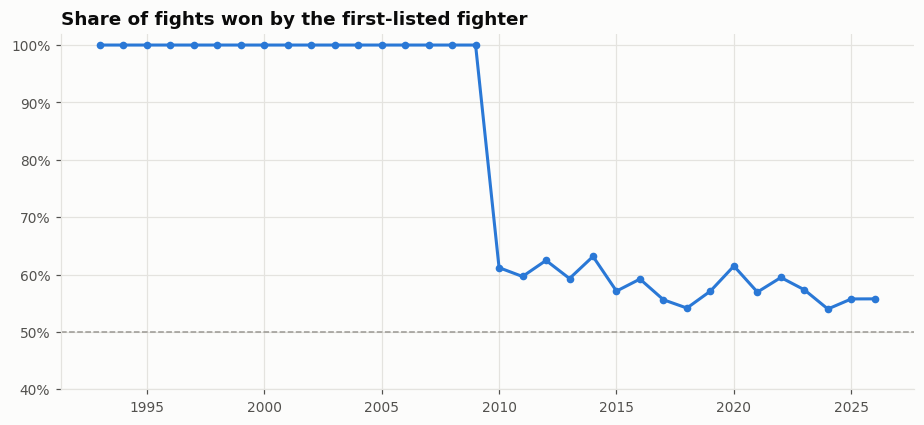

Since 2010 the red corner wins 58.0% of decided fights and is the betting favourite in 61.6% of them.


In [4]:
decided = master[master['outcome'].isin(['r', 'b'])]
first_listed_wins = (decided['outcome'] == 'r').groupby(decided['year']).mean()

ax = first_listed_wins.plot(color=plotting.BLUE, marker='o', markersize=4)
ax.axhline(0.5, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0.4, 1.02)
ax.set_title('Share of fights won by the first-listed fighter')
ax.set_xlabel('')
plt.show()

modern = decided[decided['date'] >= '2010-01-01']
with_odds = modern.dropna(subset=['r_odds', 'b_odds'])
r_favourite = (american_to_prob(with_odds['r_odds']) > american_to_prob(with_odds['b_odds'])).mean()
print(f"Since 2010 the red corner wins {(modern['outcome'] == 'r').mean():.1%} of decided fights "
      f"and is the betting favourite in {r_favourite:.1%} of them.")

Two consequences for the models:

- Taken as they are, the `r`/`b` sides leak the result: a model trained on them would learn "the first-listed fighter wins" from the early years, a rule that says nothing about fighting. The pipeline therefore draws fighter **A** at random from the two corners of each fight (fixed seed), which gives a 50/50 target in every era.
- Since 2010 the red corner does win more often, but because the UFC puts the favourite there, not because the corner itself helps. The models do not see the corner; the fighters' records carry the same information.

## 3. How fights end

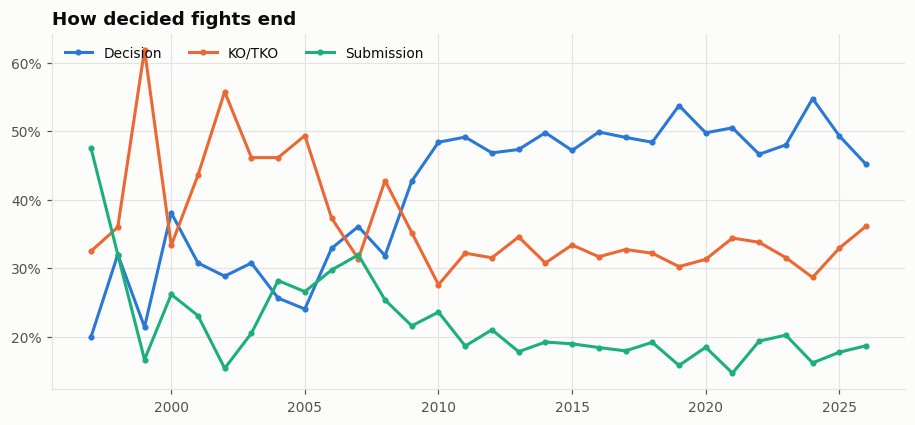

In [5]:
methods = (pd.crosstab(decided['year'], decided['method_group'], normalize='index')
           [['Decision', 'KO/TKO', 'Submission']])
methods = methods[methods.index >= 1997]

ax = methods.plot(marker='o', markersize=3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('How decided fights end')
ax.set_xlabel('')
ax.legend(title=None, ncols=3, loc='upper left')
plt.show()

Knockouts dominated the late 1990s and early 2000s. As fighters became well-rounded, decisions took over around 2009 and now settle about half the fights, while submissions have stayed below 20% since 2010.

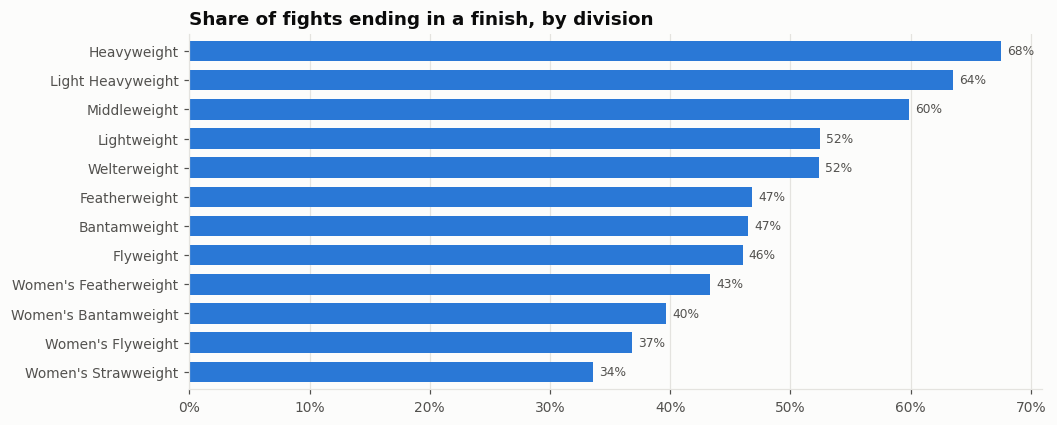

In [6]:
by_division = (decided.dropna(subset=['division'])
               .assign(finish=lambda d: d['method_group'].isin(['KO/TKO', 'Submission']))
               .groupby('division')['finish'].mean()
               .reindex(DIVISIONS).dropna().sort_values())

ax = by_division.plot.barh(color=plotting.BLUE, width=0.7)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Share of fights ending in a finish, by division')
ax.set_ylabel('')
ax.grid(axis='y', visible=False)
for y, value in enumerate(by_division):
    ax.text(value + 0.005, y, f'{value:.0%}', va='center', fontsize=8, color=plotting.INK_SECONDARY)
plt.show()

Finishing power grows with weight: two heavyweights end most of their fights early, the lightest divisions go to the judges more often than not. A fighter's finish rate therefore has to be read against their division, which the round-robin model does implicitly by comparing fighters of the same division.

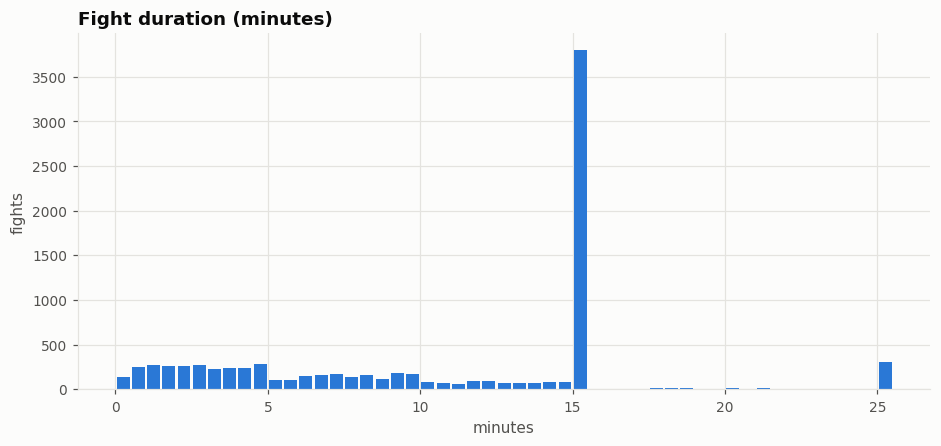

43% of fights last exactly 15 minutes (three-round decision), 3% exactly 25 (five rounds)


In [7]:
minutes = master['fight_seconds'] / 60
ax = minutes.plot.hist(bins=np.arange(0, 26, 0.5), color=plotting.BLUE, rwidth=0.85)
ax.set_title('Fight duration (minutes)')
ax.set_xlabel('minutes')
ax.set_ylabel('fights')
plt.show()
print(f"{(minutes == 15).mean():.0%} of fights last exactly 15 minutes (three-round decision), "
      f"{(minutes == 25).mean():.0%} exactly 25 (five rounds)")

Rates such as strikes per minute are computed over the real fight time, not the scheduled time: a fighter who knocks everyone out in the first round would otherwise look inactive.

## 4. Data quality

In [8]:
fields = {
    'reach': ['r_reach_cm', 'b_reach_cm'],
    'date of birth': ['r_dob', 'b_dob'],
    'height': ['r_height_cm', 'b_height_cm'],
    'stance': ['r_stance', 'b_stance'],
    'control time': ['r_ctrl_sec', 'b_ctrl_sec'],
    'betting odds': ['r_odds', 'b_odds'],
    'official rank (either fighter)': ['r_rank', 'b_rank'],
}
quality = pd.DataFrame({
    name: {'missing (all fights)': master[cols].isna().any(axis=1).mean(),
           'missing (since 2015)': master.loc[master['year'] >= 2015, cols].isna().any(axis=1).mean()}
    for name, cols in fields.items()
}).T
quality['missing (all fights)'] = quality['missing (all fights)'].map('{:.1%}'.format)
quality['missing (since 2015)'] = quality['missing (since 2015)'].map('{:.1%}'.format)
quality

,missing (all fights),missing (since 2015)
reach,12.0%,2.5%
date of birth,1.4%,0.0%
height,0.3%,0.0%
stance,1.0%,0.4%
control time,2.4%,0.0%
betting odds,25.3%,14.1%
official rank (either fighter),86.3%,81.4%


- Physical data is nearly complete; reach is the weakest field, mostly for fighters of the 1990s and 2000s.
- Control time was not recorded before UFC 21 in July 1999 (ufcstats shows 0:00 for both fighters). Those zeros are treated as missing, not as "no control".
- Odds start in 2010. Official ranks exist only for ranked fighters (top 15 of each division) and are therefore missing for most fights by nature: they are used to check the rankings, not as a model input.

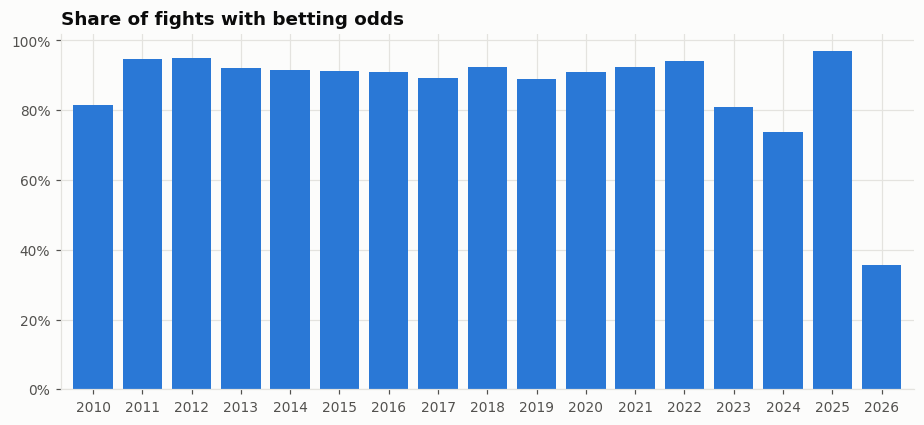

In [9]:
odds_coverage = master[master['year'] >= 2010].groupby('year')['r_odds'].apply(lambda s: s.notna().mean())
ax = odds_coverage.plot.bar(width=0.8, color=plotting.BLUE)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Share of fights with betting odds')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.show()

The odds source has gaps in 2023-2024 and stops in spring 2026: the "against the market" comparisons are always made on the fights that do have odds.

## 5. The betting market

The market is the benchmark every model is compared with. American odds are converted to implied probabilities, then normalised so that the two fighters' probabilities add up to 1 (removing the bookmaker's margin).

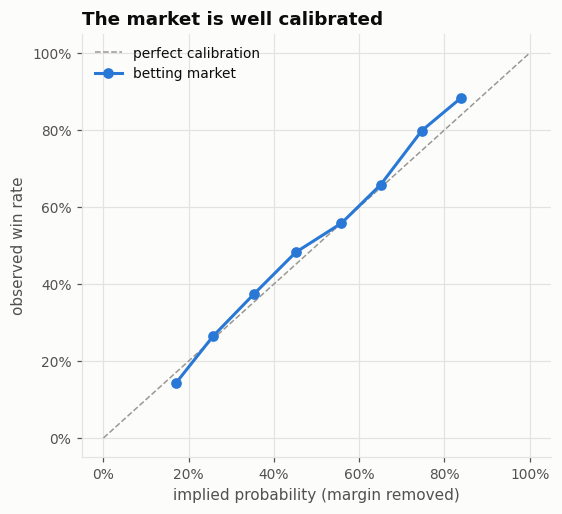

6,572 fights with odds. Median bookmaker margin: 3.7%. The favourite wins 66.7% of the time.


In [10]:
market = decided.dropna(subset=['r_odds', 'b_odds']).copy()
r_imp, b_imp = american_to_prob(market['r_odds']), american_to_prob(market['b_odds'])
market['p_r'] = r_imp / (r_imp + b_imp)
market['r_won'] = (market['outcome'] == 'r').astype(int)
margin = np.nanmedian(r_imp + b_imp - 1)

bins = np.linspace(0, 1, 11)
market['bin'] = pd.cut(market['p_r'], bins)
calibration = market.groupby('bin', observed=True).agg(predicted=('p_r', 'mean'),
                                                       observed=('r_won', 'mean'),
                                                       fights=('r_won', 'size'))
calibration = calibration[calibration['fights'] >= 30]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=plotting.NEUTRAL, linewidth=1, linestyle='--', label='perfect calibration')
ax.plot(calibration['predicted'], calibration['observed'], marker='o', color=plotting.BLUE,
        label='betting market')
ax.set_xlabel('implied probability (margin removed)')
ax.set_ylabel('observed win rate')
ax.set_title('The market is well calibrated')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='upper left')
plt.show()

favourite_won = ((market['p_r'] > 0.5) == (market['r_won'] == 1))[market['p_r'] != 0.5]
print(f"{len(market):,} fights with odds. Median bookmaker margin: {margin:.1%}. "
      f"The favourite wins {favourite_won.mean():.1%} of the time.")

When the market says 70%, the fighter wins about 70% of the time. The only visible bias is at the extremes, where heavy favourites win a little more often than their odds imply (the classic favourite-longshot bias). A model can only beat the market by finding information the market misses, which is what [03_models_and_rankings](03_models_and_rankings.ipynb) tests.